Usted ha sido contratado en el ministerio de educación para analizar los resultados de uuna nueva metodología de educación implementada en el colegio Graham Parker (GP), versus el colegio Marteen Sheen (MS), en donde no fue aplicada la metodoollogía.
Ambos colegios han tenido istóricamente ddesempeños similares en las notas de sus alumnos.

In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Obtención y limpieza de datos


In [11]:
df = pd.read_csv('notas-alumnos.csv')
df.head()

,colegio,sexo,edad,ausencias,N1,N2,N3
0,GP,F,18,6,1.8,2.1,2.1
1,GP,F,17,4,1.8,1.8,2.1
2,GP,F,15,10,2.4,2.8,3.5
3,GP,F,15,2,5.2,4.9,5.2
4,GP,F,16,4,2.1,3.5,3.5


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   colegio    395 non-null    object 
 1   sexo       395 non-null    object 
 2   edad       395 non-null    int64  
 3   ausencias  395 non-null    int64  
 4   N1         395 non-null    float64
 5   N2         395 non-null    float64
 6   N3         395 non-null    float64
dtypes: float64(3), int64(2), object(2)
memory usage: 21.7+ KB


In [ ]:
# Revisar nulos
df.isna().sum()

colegio      0
sexo         0
edad         0
ausencias    0
N1           0
N2           0
N3           0
dtype: int64

In [ ]:
# Revisar duplicados
duplicadas = df.duplicated().sum()
print("Filas duplicadas:", duplicadas)

# Eliminar filas duplicadas
if duplicadas > 0:
    df = df.drop_duplicates()
print("Filas y columnas después de eliminar duplicados:", df.shape)

Filas duplicadas: 0
Filas y columnas después de eliminar duplicados: (387, 7)


In [ ]:
df.describe(include="all")

,colegio,sexo,edad,ausencias,N1,N2,N3
count,387,387,387.000000,387.000000,387.000000,387.000000,387.000000
unique,2,2,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,NaN,NaN,NaN,NaN
freq,342,203,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.687339,5.770026,3.827649,3.765116,3.662016
std,NaN,NaN,1.280754,8.061379,1.169423,1.306579,1.590330
min,NaN,NaN,15.000000,0.000000,1.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,0.000000,2.800000,3.200000,2.800000
50%,NaN,NaN,17.000000,4.000000,3.900000,3.900000,3.900000
75%,NaN,NaN,18.000000,8.000000,4.600000,4.600000,4.900000


# Análisis exploratorio de datos

In [38]:
# Promedios por colegio
df.groupby("colegio")[["N1","N2","N3"]].mean()

,N1,N2,N3
colegio,,,
GP,3.838596,3.788304,3.689181
MS,3.744444,3.588889,3.455556


In [ ]:
# Crear columna con el promedio de las notas
df["promedio"] = df[["N1", "N2", "N3"]].mean(axis=1)

In [44]:
media_x_colegio = df.groupby("colegio")["promedio"].mean()
print(media_x_colegio)

colegio
GP    3.772027
MS    3.596296
Name: promedio, dtype: float64


In [45]:
# Rango de variación
rv = df["promedio"].max() - df["promedio"].min()
print("Rango de variación del promedio:", rv)

Rango de variación del promedio: 6.266666666666667


In [47]:
# Varianza
df["promedio"].var(ddof=0)

np.float64(1.6556413024205423)

In [48]:
# Desviación estándar
df["promedio"].std(ddof=0)

np.float64(1.2867172581498012)

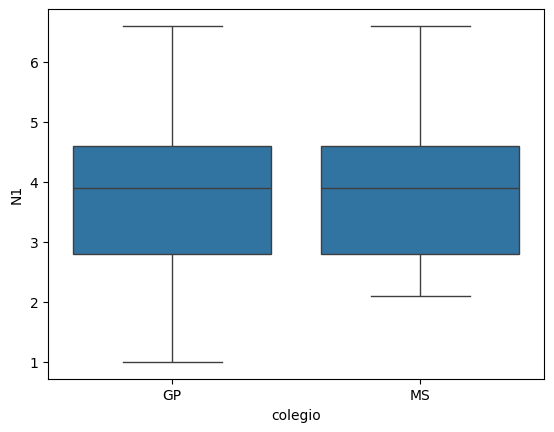

In [24]:
# Distribución de notas por colegio
sns.boxplot(x="colegio", y="N1", data=df)
plt.show()

In [51]:
# Promedio de ausencias por colegio
promedio_ausencias = df.groupby("colegio")["ausencias"].mean()
print(promedio_ausencias)

colegio
GP    6.035088
MS    3.755556
Name: ausencias, dtype: float64


In [54]:
lm = smf.ols(data=df, formula="promedio ~ colegio").fit()

In [55]:
lm.params

Intercept        3.772027
colegio[T.MS]   -0.175731
dtype: float64

In [56]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               promedio   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7393
Date:                Fri, 20 Feb 2026   Prob (F-statistic):              0.390
Time:                        21:45:38   Log-Likelihood:                -646.32
No. Observations:                 387   AIC:                             1297.
Df Residuals:                     385   BIC:                             1305.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.7720      0.070     54.125      0.000       3.635       3.909
colegio[T.MS]    -0.1757      0.204     -0.860      0.390      -0.578       0.226
==============================================================================
Omnibus:                        3.812   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.149   Jarque-Bera (JB):                3.396
Skew:                          -0.154   Prob(JB):                        0.183
Kurtosis:                       2.660   Cond. No.                         3.17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## El R^2 es ajustado, hipotesis nula ???

# Planteamiento del problema

Queremos evaluar si la nueva metodología aplicada en GP produjo un cambio significativo en el rendimiento respecto a MS
**Hipótesis**:
- $H_0$: No hay diferencia en las notas entre GP y MS
- $H_1$: Sí hay diferencia significativa en las notas entre GP y MS

# Selección y justificación del test estadístico

# Cálculos y procedimientos

# Interprertación y conclusión